# PySR Basics - Symbolic Regression

This notebook demonstrates how to use PySR to discover mathematical expressions from data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1. Generate Data

True function: f(x) = x² + 2*sin(x)

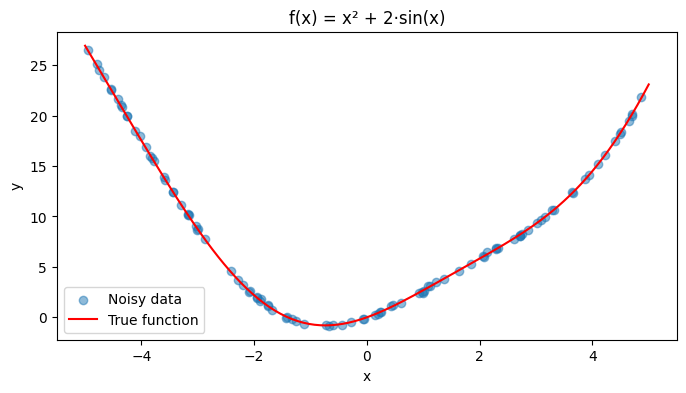

In [2]:
# Generate data
np.random.seed(42)
n_samples = 100

X = np.random.uniform(-5, 5, (n_samples, 1))
y = X[:, 0]**2 + 2 * np.sin(X[:, 0])

# Add small noise
y_noisy = y + np.random.normal(0, 0.1, n_samples)

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(X, y_noisy, alpha=0.5, label='Noisy data')
X_plot = np.linspace(-5, 5, 200).reshape(-1, 1)
y_true = X_plot[:, 0]**2 + 2 * np.sin(X_plot[:, 0])
plt.plot(X_plot, y_true, 'r-', label='True function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('f(x) = x² + 2·sin(x)')
plt.show()

## 2. Fit PySR Model

In [3]:
# Create PySR model
model = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "square"],
    populations=15,
    population_size=33,
    maxsize=20,
    verbosity=1,
)

# Fit model
model.fit(X, y_noisy)

/Users/drorjac/miniforge3/envs/fieldsense/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.927e+01  0.000e+00  y = 8.9508
2           2.157e+00  3.313e+00  y = square(x₀)
4           1.989e+00  4.039e-02  y = square(x₀ + -0.068783)
5           5.518e-01  1.282e+00  y = sin(x₀) + square(x₀)
7           8.174e-03  2.106e+00  y = (sin(x₀) * 2.0121) + square(x₀)
9           7.938e-03  1.463e-02  y = square(x₀) + (cos(x₀ - -4.7012) * 2.0115)
11          7.828e-03  6.972e-03  y = (sin(x₀ + -0.010612) * 2.0075) + square(x₀ - 0.0018343...
                                      )
13          7.754e-03  4.791e-03  y = ((sin(x₀) * 2.0062) + square(0.0018106 - (x₀ / 0.99892...
                                      ))) - 0.020454
14          7.659e-03  1.231e-02  y = ((sin(x₀) * 2.0118) + square(x₀)) - ((x₀ / sin(x₀)) * ...
                                      0.00051728)
15          7.547e-03  1.478e-02  y = ((sin(x₀) * 2.015) + squ

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                           8.950849   
	1         3.313492                                         square(x0)   
	2         0.040392                           square(x0 + -0.06878259)   
	3         1.282451                               sin(x0) + square(x0)   
	4   >>>>  2.106091                 (sin(x0) * 2.0121145) + square(x0)   
	5         0.014631     square(x0) + (cos(x0 - -4.701233) * 2.0115159)   
	6         0.006972  (sin(x0 + -0.0106122745) * 2.0074785) + square...   
	7         0.004791  ((sin(x0) * 2.0062425) + square(0.0018105799 -...   
	8         0.012308  ((sin(x0) * 2.011803) + square(x0)) - ((x0 / s...   
	9         0.014781  ((sin(x0) * 2.014987) + square(x0)) - (0.03770...   
	10        0.001241  (sin(x0 - (sin(sin(exp(x0 + -0.34130007))) * 0...   
	11        0.035251  (sin(x0 - (sin(exp((x0 + x0) + x0)) * 0.038374...   
	12        0.000221  square(0.002214034 - x0) + (sin(x0 - (sin(exp(...   
	
	         loss  complexity  
	0   59.271330           1  
	1    2.156818           2  
	2    1.989435           4  
	3    0.551783           5  
	4    0.008174           7  
	5    0.007938           9  
	6    0.007828          11  
	7    0.007754          13  
	8    0.007659          14  
	9    0.007547          15  
	10   0.007537          16  
	11   0.007276          17  
	12   0.007273          19  
]

  - outputs/20251210_163558_PiQwm1/hall_of_fame.csv


## 3. View Discovered Equations

In [4]:
# Show Pareto front of equations
print(model)

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                           8.950849   
	1         3.313492                                         square(x0)   
	2         0.040392                           square(x0 + -0.06878259)   
	3         1.282451                               sin(x0) + square(x0)   
	4   >>>>  2.106091                 (sin(x0) * 2.0121145) + square(x0)   
	5         0.014631     square(x0) + (cos(x0 - -4.701233) * 2.0115159)   
	6         0.006972  (sin(x0 + -0.0106122745) * 2.0074785) + square...   
	7         0.004791  ((sin(x0) * 2.0062425) + square(0.0018105799 -...   
	8         0.012308  ((sin(x0) * 2.011803) + square(x0)) - ((x0 / s...   
	9         0.014781  ((sin(x0) * 2.014987) + square(x0)) - (0.03770...   
	10        0.001241  (sin(x0 - (sin(sin(exp(x0 + -0.34130007))) * 0...   
	11        0.035251  (sin(x0 - (sin(exp((x0 + x0) + x0)) * 0.038374...   
	12      

In [5]:
# Best equation
print("Best equation:", model.sympy())

Best equation: x0**2 + sin(x0)*2.0121145


## 4. Validate Model

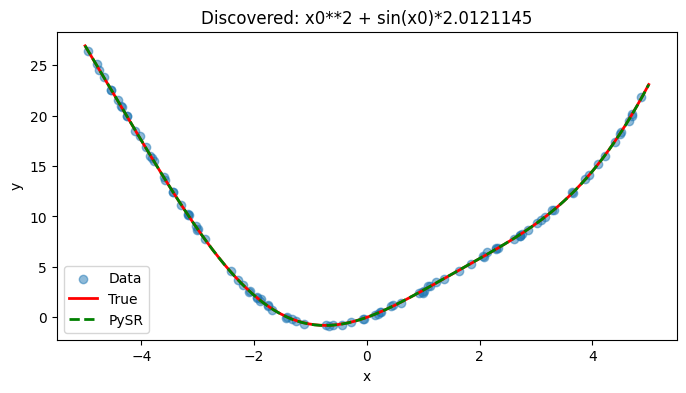

In [6]:
# Predict
y_pred = model.predict(X_plot)

# Plot comparison
plt.figure(figsize=(8, 4))
plt.scatter(X, y_noisy, alpha=0.5, label='Data')
plt.plot(X_plot, y_true, 'r-', label='True', linewidth=2)
plt.plot(X_plot, y_pred, 'g--', label='PySR', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'Discovered: {model.sympy()}')
plt.show()

## 5. Multi-variable Example

True function: f(x, y) = x·y + y²

In [7]:
# Generate 2D data
np.random.seed(42)
n_samples = 200

X2 = np.random.uniform(-3, 3, (n_samples, 2))
y2 = X2[:, 0] * X2[:, 1] + X2[:, 1]**2
y2_noisy = y2 + np.random.normal(0, 0.1, n_samples)

In [8]:
# Fit model
model2 = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*"],
    unary_operators=["square"],
    populations=15,
    maxsize=15,
    verbosity=1,
)

model2.fit(X2, y2_noisy)

/Users/drorjac/miniforge3/envs/fieldsense/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.693e+01  0.000e+00  y = 3.1047
2           9.511e+00  5.765e-01  y = square(x₁)
4           9.445e+00  3.500e-03  y = square(x₁ + -0.075817)
5           9.709e-03  6.880e+00  y = (x₁ + x₀) * x₁
6           9.709e-03  1.192e-07  y = (x₀ * x₁) + square(x₁)
7           9.671e-03  3.917e-03  y = (x₁ * 0.99881) * (x₀ + x₁)
9           9.654e-03  8.777e-04  y = ((x₁ + x₀) * (0.99821 * x₁)) + 0.0051493
10          9.640e-03  1.456e-03  y = (x₁ + x₀) * (x₁ - (square(x₀) * 0.00061844))
11          9.609e-03  3.152e-03  y = (x₁ - square(square(x₀ * -0.10099))) * (x₁ + x₀)
12          9.600e-03  9.520e-04  y = ((x₁ - (square(x₀) * 0.00062609)) * (x₁ + x₀)) * 0.998...
                                      78
13          9.360e-03  2.538e-02  y = (x₁ + x₀) * (x₁ - ((x₀ - x₁) * (x₀ * 0.0024427)))
15          9.343e-03  8.967e-04  y = (x₁ - ((x₀ 

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                          3.1046999   
	1         5.765286e-01                                         square(x1)   
	2         3.500285e-03                           square(x1 + -0.07581652)   
	3   >>>>  6.880170e+00                                     (x1 + x0) * x1   
	4         1.029999e-07                             (x0 * x1) + square(x1)   
	5         3.917022e-03                       (x1 * 0.9988115) * (x0 + x1)   
	6         8.776885e-04      ((x1 + x0) * (0.9982054 * x1)) + 0.0051492867   
	7         1.455611e-03    (x1 + x0) * (x1 - (square(x0) * 0.00061843806))   
	8         3.152230e-03  (x1 - square(square(x0 * -0.10098931))) * (x1 ...   
	9         9.519119e-04  ((x1 - (square(x0) * 0.00062609254)) * (x1 + x...   
	10        2.538204e-02  (x1 + x0) * (x1 - ((x0 - x1) * (x0 * 0.0024427...   
	11        8.967190e-04  (x1 - ((x0 * 0.0028636677) * ((x0 * 0.86457795...   
	
	         loss  complexity  
	0   16.928040           1  
	1    9.510941           2  
	2    9.444591           4  
	3    0.009709           5  
	4    0.009709           6  
	5    0.009671           7  
	6    0.009654           9  
	7    0.009640          10  
	8    0.009609          11  
	9    0.009600          12  
	10   0.009360          13  
	11   0.009343          15  
]

  - outputs/20251210_163611_zqXqgh/hall_of_fame.csv


In [9]:
print("Best equation:", model2.sympy())

Best equation: x1*(x0 + x1)


## 6. Exercise

Try:
- Different operators (add `log`, `sqrt`)
- More/less iterations
- Different noise levels
- Your own functions

In [10]:
# Your experiments here
